### Buffalo 331 Service Exploratory Data Analytics

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#input the path to read the csv file
filePath = input("Input the path to the csv file: ")
if "cleaned" in filePath and "311" in filePath:
    df = pd.read_csv(filePath, low_memory = False)
else:
    print("Incorrect file path!")
    filePath = input("Input the correct cleaned Buffalo 331 Cleaned csv file:")
    #C:\Users\meena\Projects\CSE 487\data\cleaned_311.csv
    #/cleaned_311.csv

Input the path to the csv file: /cleaned_311.csv


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524477 entries, 0 to 524476
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   caseId           524477 non-null  object 
 1   createdDate      524477 non-null  object 
 2   closedDate       510692 non-null  object 
 3   status           524477 non-null  object 
 4   department       524476 non-null  object 
 5   type             524477 non-null  object 
 6   addressNumber    516423 non-null  object 
 7   street           524148 non-null  object 
 8   zip              516057 non-null  float64
 9   latitude         225693 non-null  float64
 10  longitude        225693 non-null  float64
 11  councilDistrict  524477 non-null  object 
 12  policeDistrict   521635 non-null  object 
 13  neighborhood     521628 non-null  object 
 14  censusTract      520748 non-null  float64
 15  source           524477 non-null  object 
 16  isOpen           524477 non-null  bool

In [4]:
#idk why when I read the file the dates were converted to objects again, so I changed the types to date and time again
df['createdDate'] = pd.to_datetime(df['createdDate'])
df['closedDate'] = pd.to_datetime(df['closedDate'])

In [5]:
#extract date & month col to create a graph
df['createdYear'] = df['createdDate'].dt.year
df['createdMonth'] = df['createdDate'].dt.month


In [6]:
df

,caseId,createdDate,closedDate,status,department,type,addressNumber,street,zip,latitude,longitude,councilDistrict,policeDistrict,neighborhood,censusTract,source,isOpen,createdYear,createdMonth
0,1001098002,2020-01-01 10:28:00,2020-01-02 11:19:00,Closed,Parking Department,Parking Enforcement & Rules,99,GOETHE,14206.0,NaN,NaN,LOVEJOY,District C,Lovejoy,2300.0,old,False,2020,1
1,380751-1001098003,2020-01-01 11:01:00,2020-01-02 11:20:00,Closed,Parking Department,Parking Enforcement & Rules,63,VERNON,14214.0,NaN,NaN,MASTEN,District D,Parkside,4002.0,old,False,2020,1
2,1001098004,2020-01-01 11:48:00,2020-01-03 13:20:00,Closed,"Public Works, Parks, & Streets Department",Violations & Inspections,568,AMHERST ST,14207.0,NaN,NaN,NORTH,District D,Grant-Amherst,5500.0,old,False,2020,1
3,1001098005,2020-01-01 11:51:00,2020-01-02 09:29:00,Closed,Buffalo Police Department,Nuisance & Quality of Life,47,MASSACHUSETTS,14213.0,NaN,NaN,NIAGARA,District B,West Side,7000.0,old,False,2020,1
4,1001098006,2020-01-01 11:54:00,2020-01-02 14:09:00,Closed,"Public Works, Parks, & Streets Department",Illegal Dumping & Debris,47,MASSACHUSETTS,14213.0,NaN,NaN,NIAGARA,District B,West Side,7000.0,old,False,2020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
524472,01429055,2026-09-25 23:20:00,NaT,New,"Public Works, Parks, & Streets Department",Traffic & Lines,414,PORTER,14201.0,42.903055,-78.887221,NIAGARA,District B,West Side,6904.0,new,True,2026,9
524473,01429059,2026-09-26 00:35:00,NaT,New,"Public Works, Parks, & Streets Department",Roads & Potholes,330,POTTERS,14220.0,42.840300,-78.801140,SOUTH,District A,South Park,1000.0,new,True,2026,9
524474,01429061,2026-09-26 01:53:00,NaT,New,Parking Department,Parking Enforcement & Rules,67,PARK,14201.0,42.898785,-78.875593,FILLMORE,District B,Allentown,6802.0,new,True,2026,9
524475,01429063,2026-09-26 02:13:00,NaT,New,"Public Works, Parks, & Streets Department",Tree Maintenance,213,WINSLOW,14208.0,42.912856,-78.844903,MASTEN,District C,Masten Park,3302.0,new,True,2026,9


## Montly Service Trends based Year
This section is to see the trends of how many cases each month has per year

### Prominent Cases from 2020-2026

Text(0, 0.5, 'Number of cases')

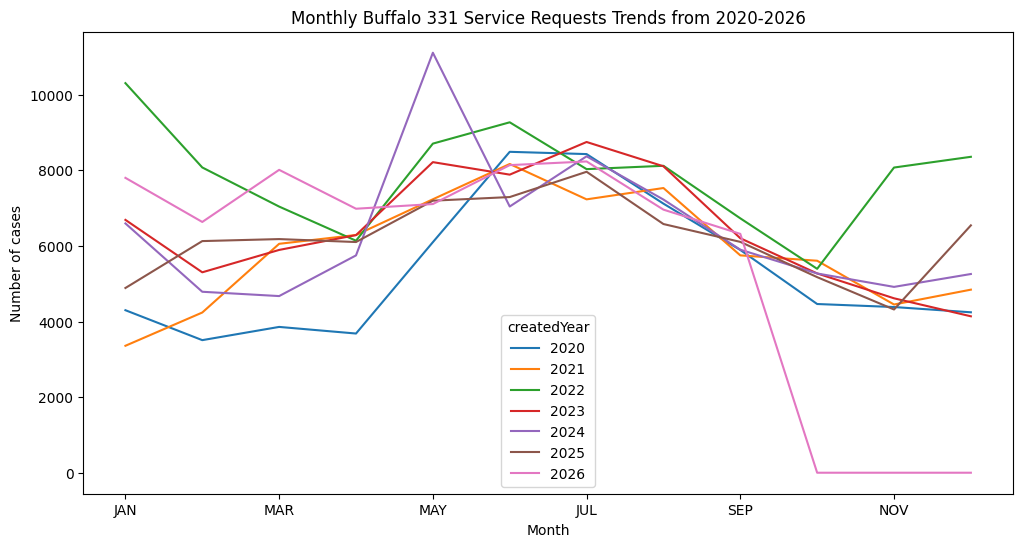

In [45]:


years = list(range(2020,2027))
years_df = df[df['createdYear'].isin(years)]

counts_df = pd.crosstab(years_df['createdMonth'],years_df['createdYear'])


months = {1:'JAN',2:'FEB',3:'MAR',4:'APR',5:'MAY',6:'JUN',7:'JUL',8:'AUG',9:'SEP',10:'OCT',11: 'NOV',12 :'DEC'}
counts_df.index = counts_df.index.map(months)
counts_df.plot(kind='line', figsize=(12,6))

plt.title("Monthly Buffalo 331 Service Requests Trends from 2020-2026")
plt.xlabel('Month')
plt.ylabel('Number of cases')


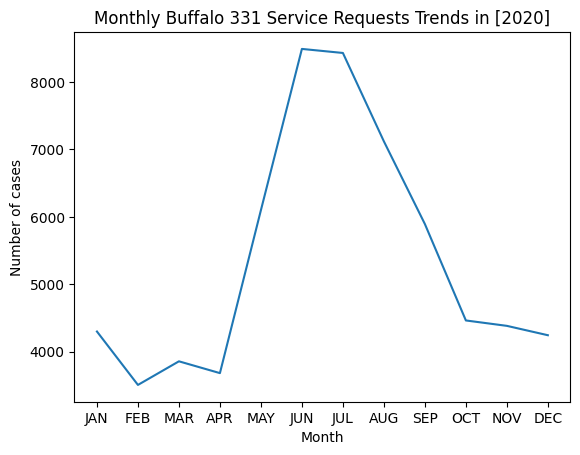

In [90]:


cases2020= df[(df['createdYear'] == 2020)]
def cases_per_month(cases_year, cases_month):
  return len(cases_year[(cases_year['createdMonth']==cases_month)])
months = [1,2,3,4,5,6,7,8,9,10,11,12]
def plot_graph(cases_year):
  month_totals = {"jan":cases_per_month(cases_year,1), "feb" : cases_per_month(cases_year,2), "mar" : cases_per_month(cases_year,3),
                    "apr" :cases_per_month(cases_year,4), "may":cases_per_month(cases_year,5), "jun":cases_per_month(cases_year,6),
                    "jul":cases_per_month(cases_year,7), "aug" : cases_per_month(cases_year,8), "sep": cases_per_month(cases_year,9),
                    "oct": cases_per_month(cases_year,10), "nov": cases_per_month(cases_year,11), "dec" :cases_per_month(cases_year,12)}
  cases_months = [ month.upper()  for month in month_totals.keys()]
  cases_freq= list(month_totals.values())
  plt.plot(cases_months,cases_freq)
  plt.title("Monthly Buffalo 331 Service Requests Trends in " + f'{cases_year['createdYear'].unique()}')
  plt.xlabel('Month')
  plt.ylabel('Number of cases')
  plt.show()
plot_graph(cases2020)

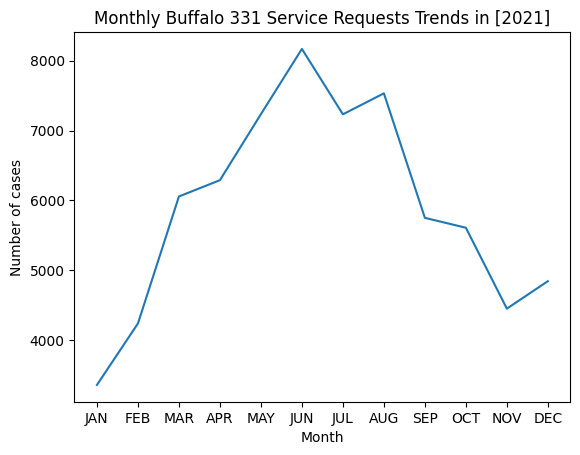

In [93]:
cases2021= df[(df['createdYear'] == 2021)]
plot_graph(cases2021)

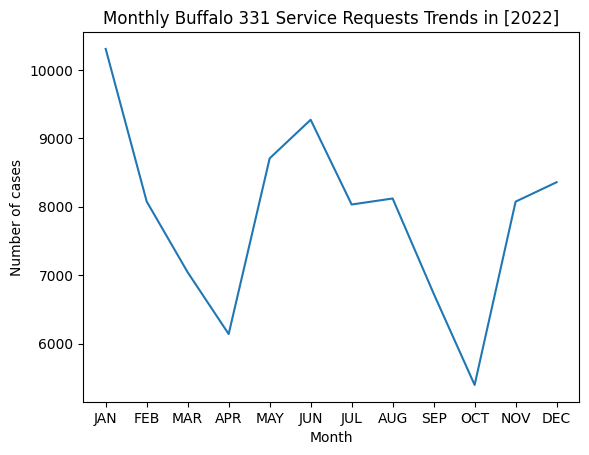

In [94]:
cases2022= df[(df['createdYear'] == 2022)]
plot_graph(cases2022)

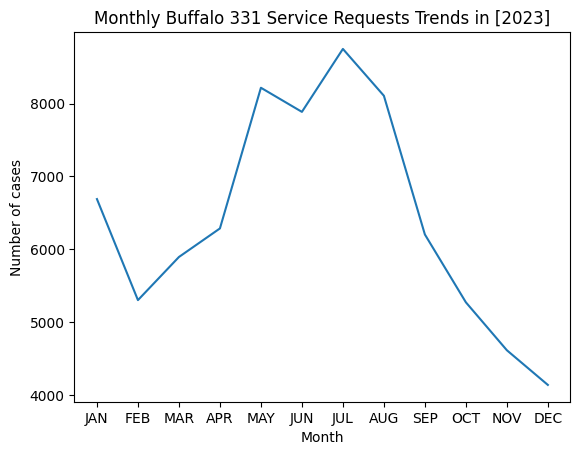

In [95]:
cases2023= df[(df['createdYear'] == 2023)]
plot_graph(cases2023)

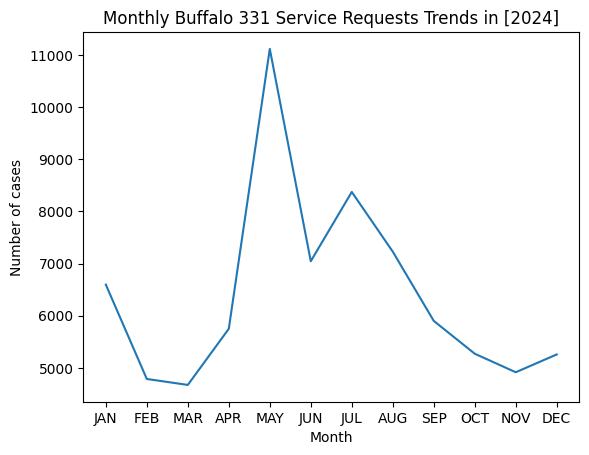

In [96]:
cases2024= df[(df['createdYear'] == 2024)]
plot_graph(cases2024)

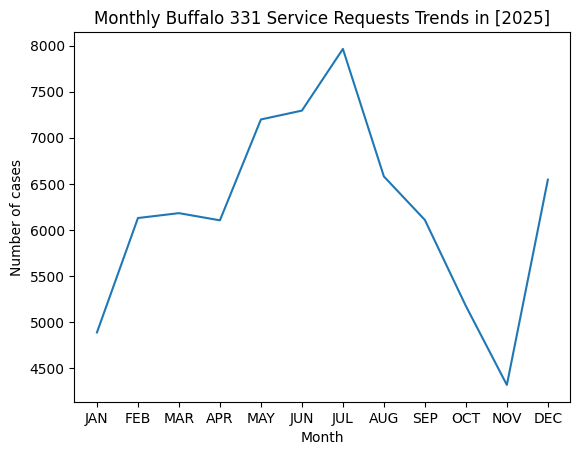

In [97]:
cases2025= df[(df['createdYear'] == 2025)]
plot_graph(cases2025)

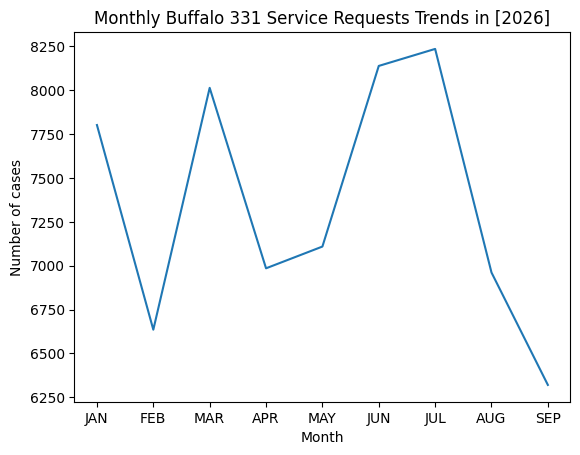

In [69]:
cases2026= df[(df['createdYear'] == 2026)]
def plot_graph2(cases_year):
  month_totals = {"jan":cases_per_month(cases_year,1), "feb" : cases_per_month(cases_year,2), "mar" : cases_per_month(cases_year,3),
                    "apr" :cases_per_month(cases_year,4), "may":cases_per_month(cases_year,5), "jun":cases_per_month(cases_year,6),
                    "jul":cases_per_month(cases_year,7), "aug" : cases_per_month(cases_year,8), "sep": cases_per_month(cases_year,9),
                  }
  cases_months = [ month.upper()  for month in month_totals.keys()]
  cases_freq= list(month_totals.values())
  plt.plot(cases_months,cases_freq)
  plt.title("Monthly Buffalo 331 Service Requests Trends in " + f'{cases_year['createdYear'].unique()}')
  plt.xlabel('Month')
  plt.ylabel('Number of cases')
  plt.show()
plot_graph2(cases2026)

### Top 5 Service Requests Per Year

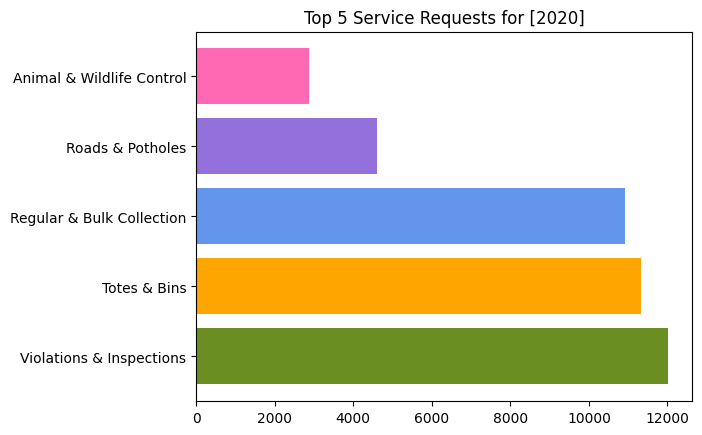

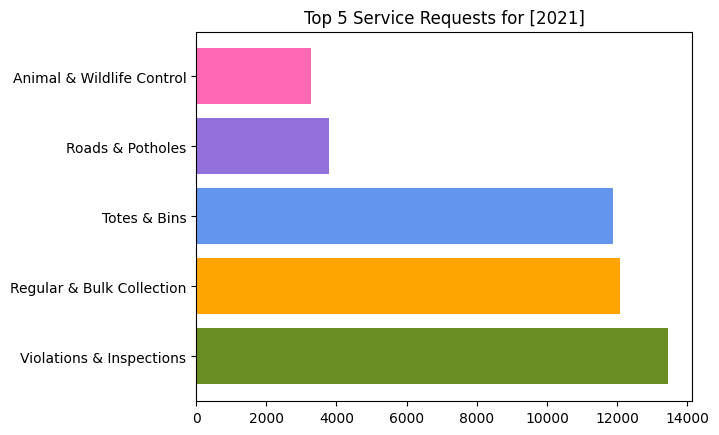

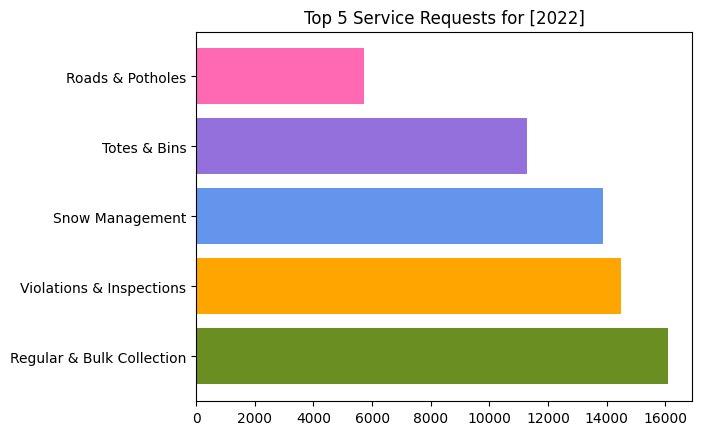

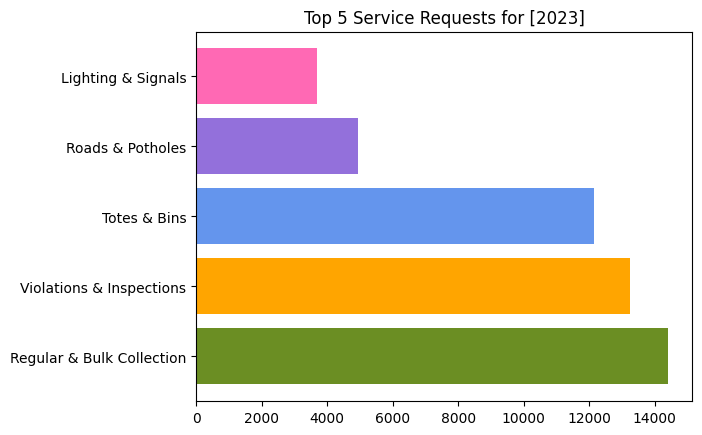

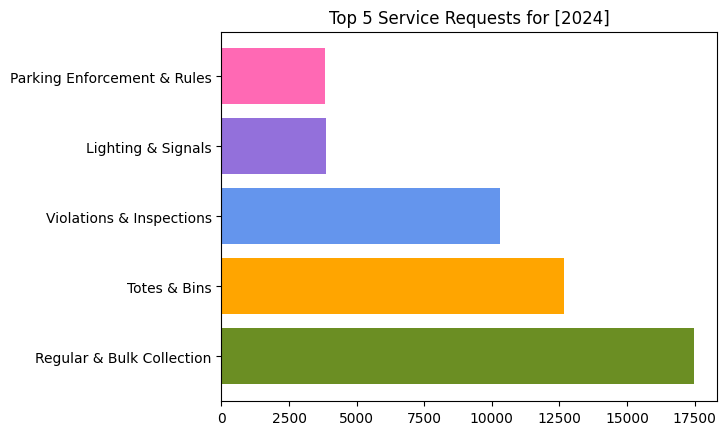

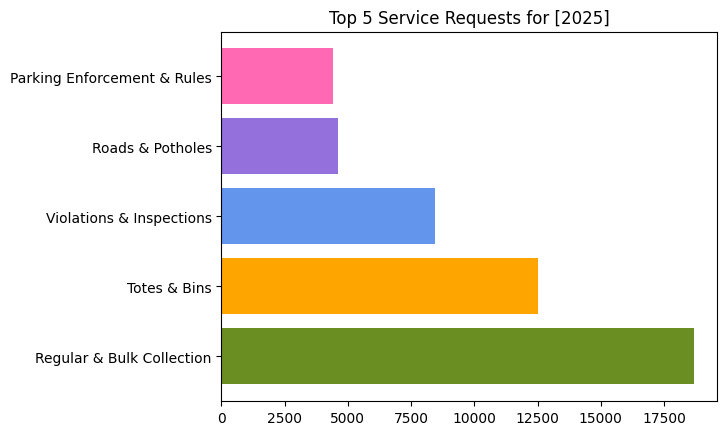

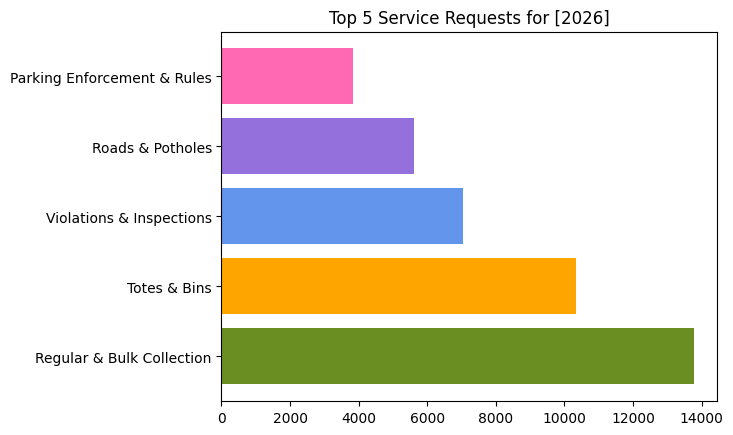

In [100]:
def plot_services(cases_year):
  cases_dict = cases_year['type'].value_counts().head(5).to_dict()
  colors_lst = ['olivedrab', 'Orange', 'cornflowerblue', 'mediumpurple', 'hotpink']
  plt.barh(cases_dict.keys(),cases_dict.values(),color=colors_lst)
  plt.title ("Top 5 Service Requests for " + f'{cases_year['createdYear'].unique()}')
  plt.show()
plot_services(cases2020)
plot_services(cases2021)
plot_services(cases2022)
plot_services(cases2023)
plot_services(cases2024)
plot_services(cases2025)
plot_services(cases2026)





### Total Requests per District (2020-2026)

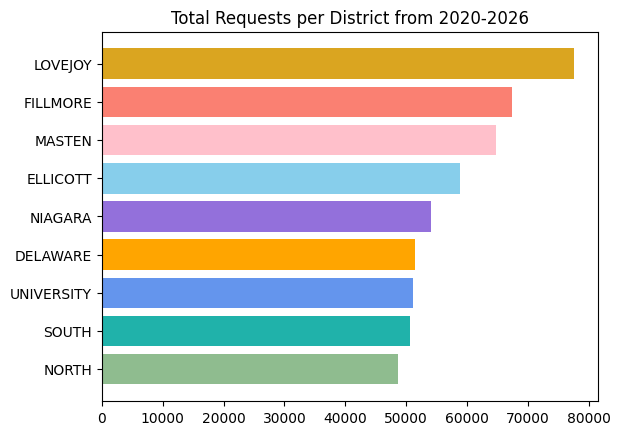

In [109]:
lst_district = list(df['councilDistrict'].unique())
map_district = {}
for district in lst_district:
  map_district[district] = len(df[(df['councilDistrict'] == district)])
map_district = dict(sorted(map_district.items(),key=lambda item: item[1]))
colors_lst = ['darkseagreen','lightseagreen', 'cornflowerblue',
              'Orange','mediumpurple', 'skyblue','pink','salmon','goldenrod']

bar_plot = plt.barh(map_district.keys(), map_district.values(), color=colors_lst )
plt.title( "Total Requests per District from 2020-2026")
plt.show()



In [119]:
df['resolutionDays'] = (df['closedDate'] - df['createdDate']).dt.total_seconds() / 86400
#Filter out closed cases with negative durations (data anomalies)
valid_closed = df[df['resolutionDays'] >= 0]
#Summary statistics by department
dept_resolution = valid_closed.groupby('department')['resolutionDays'].agg(
    mean_days='mean',
    median_days='median',
    count='count'
).sort_values(by='median_days', ascending=False)

print("Resolution Times by Department (in Days):")
dept_resolution['mean_days'] = dept_resolution['mean_days'].round(1)
dept_resolution['median_days'] = dept_resolution['median_days'].round(1)
dept_resolution.columns = ['Mean Days to Close', 'Median Days to Close','Total Cases']
display(dept_resolution)


Resolution Times by Department (in Days):


,Mean Days to Close,Median Days to Close,Total Cases
department,,,
National Grid,22.4,20.1,5457
Mayor's Office,30.5,16.3,188
City Clerk,71.4,15.0,499
Buffalo Sewer Authority,20.6,13.2,3732
Buffalo Water,19.7,12.9,3877
Office of the Mayor,65.6,12.5,2026
Buffalo Municipal Housing Authority,15.7,10.9,1906
Utilities,15.5,10.7,15570
Buffalo Fire Department,12.9,10.6,680


In [130]:
# Top 10 Census Tracts with the highest service request volume
top_tracts = df['censusTract'].value_counts().head(10).reset_index()
top_tracts.columns = ['censusTract', 'total_requests']
print("Top 10 Census Tracts by Request Volume:")
top_tracts['censusTract'] = top_tracts['censusTract'].astype(int)
top_tracts

Top 10 Census Tracts by Request Volume:


,censusTract,total_requests
0,200,15035
1,2400,12738
2,4300,11221
3,3700,10730
4,4500,10499
5,1000,10222
6,4100,10195
7,6100,10037
8,5500,8542
9,4200,8523
